### Objective of the Project

The purpose of this project is to analyze customer behavior and utilize this information through predictive and unsupervised machine learning methods to derive actionable business insight. This project will be capable of:

- Performing EDA to uncover customer attributes and behavior patterns.
- Creating a prediction model to determine customer churn rate.
- Segmenting customers based on behavior and attributes.
- Comparing customer churn behavior among different customer segments.
- Interpreting business implications from these patterns.

In [259]:
import pandas as pd
import numpy as np
# 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
# 
from special_use_classes import OutlierHandling
import special_use_classes
import importlib
importlib.reload(special_use_classes)
# 
import matplotlib.pyplot as plt
import seaborn as sns
# 
outlier_handler = OutlierHandling()

### data loading

In [260]:
mydata = pd.read_csv(r'data\BankChurners.csv')

# EDA

In [261]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

dropping the last two columns

In [262]:
columns_list = mydata.columns.tolist()
print(columns_list)
df = mydata.drop(columns=columns_list[-2:])
df = df.drop(columns='CLIENTNUM')

['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']


In [263]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [264]:
for i in df.select_dtypes('object').columns:
    df[i] = df[i].str.lower()
for i in df.select_dtypes('object').columns:
    df[i] = df[i].str.strip()

df.select_dtypes('object').head()

,Attrition_Flag,Gender,Education_Level,Marital_Status,Income_Category,Card_Category
0,existing customer,m,high school,married,$60k - $80k,blue
1,existing customer,f,graduate,single,less than $40k,blue
2,existing customer,m,graduate,married,$80k - $120k,blue
3,existing customer,f,high school,unknown,less than $40k,blue
4,existing customer,m,uneducated,married,$60k - $80k,blue


### we have many outliers in our data

<Axes: >

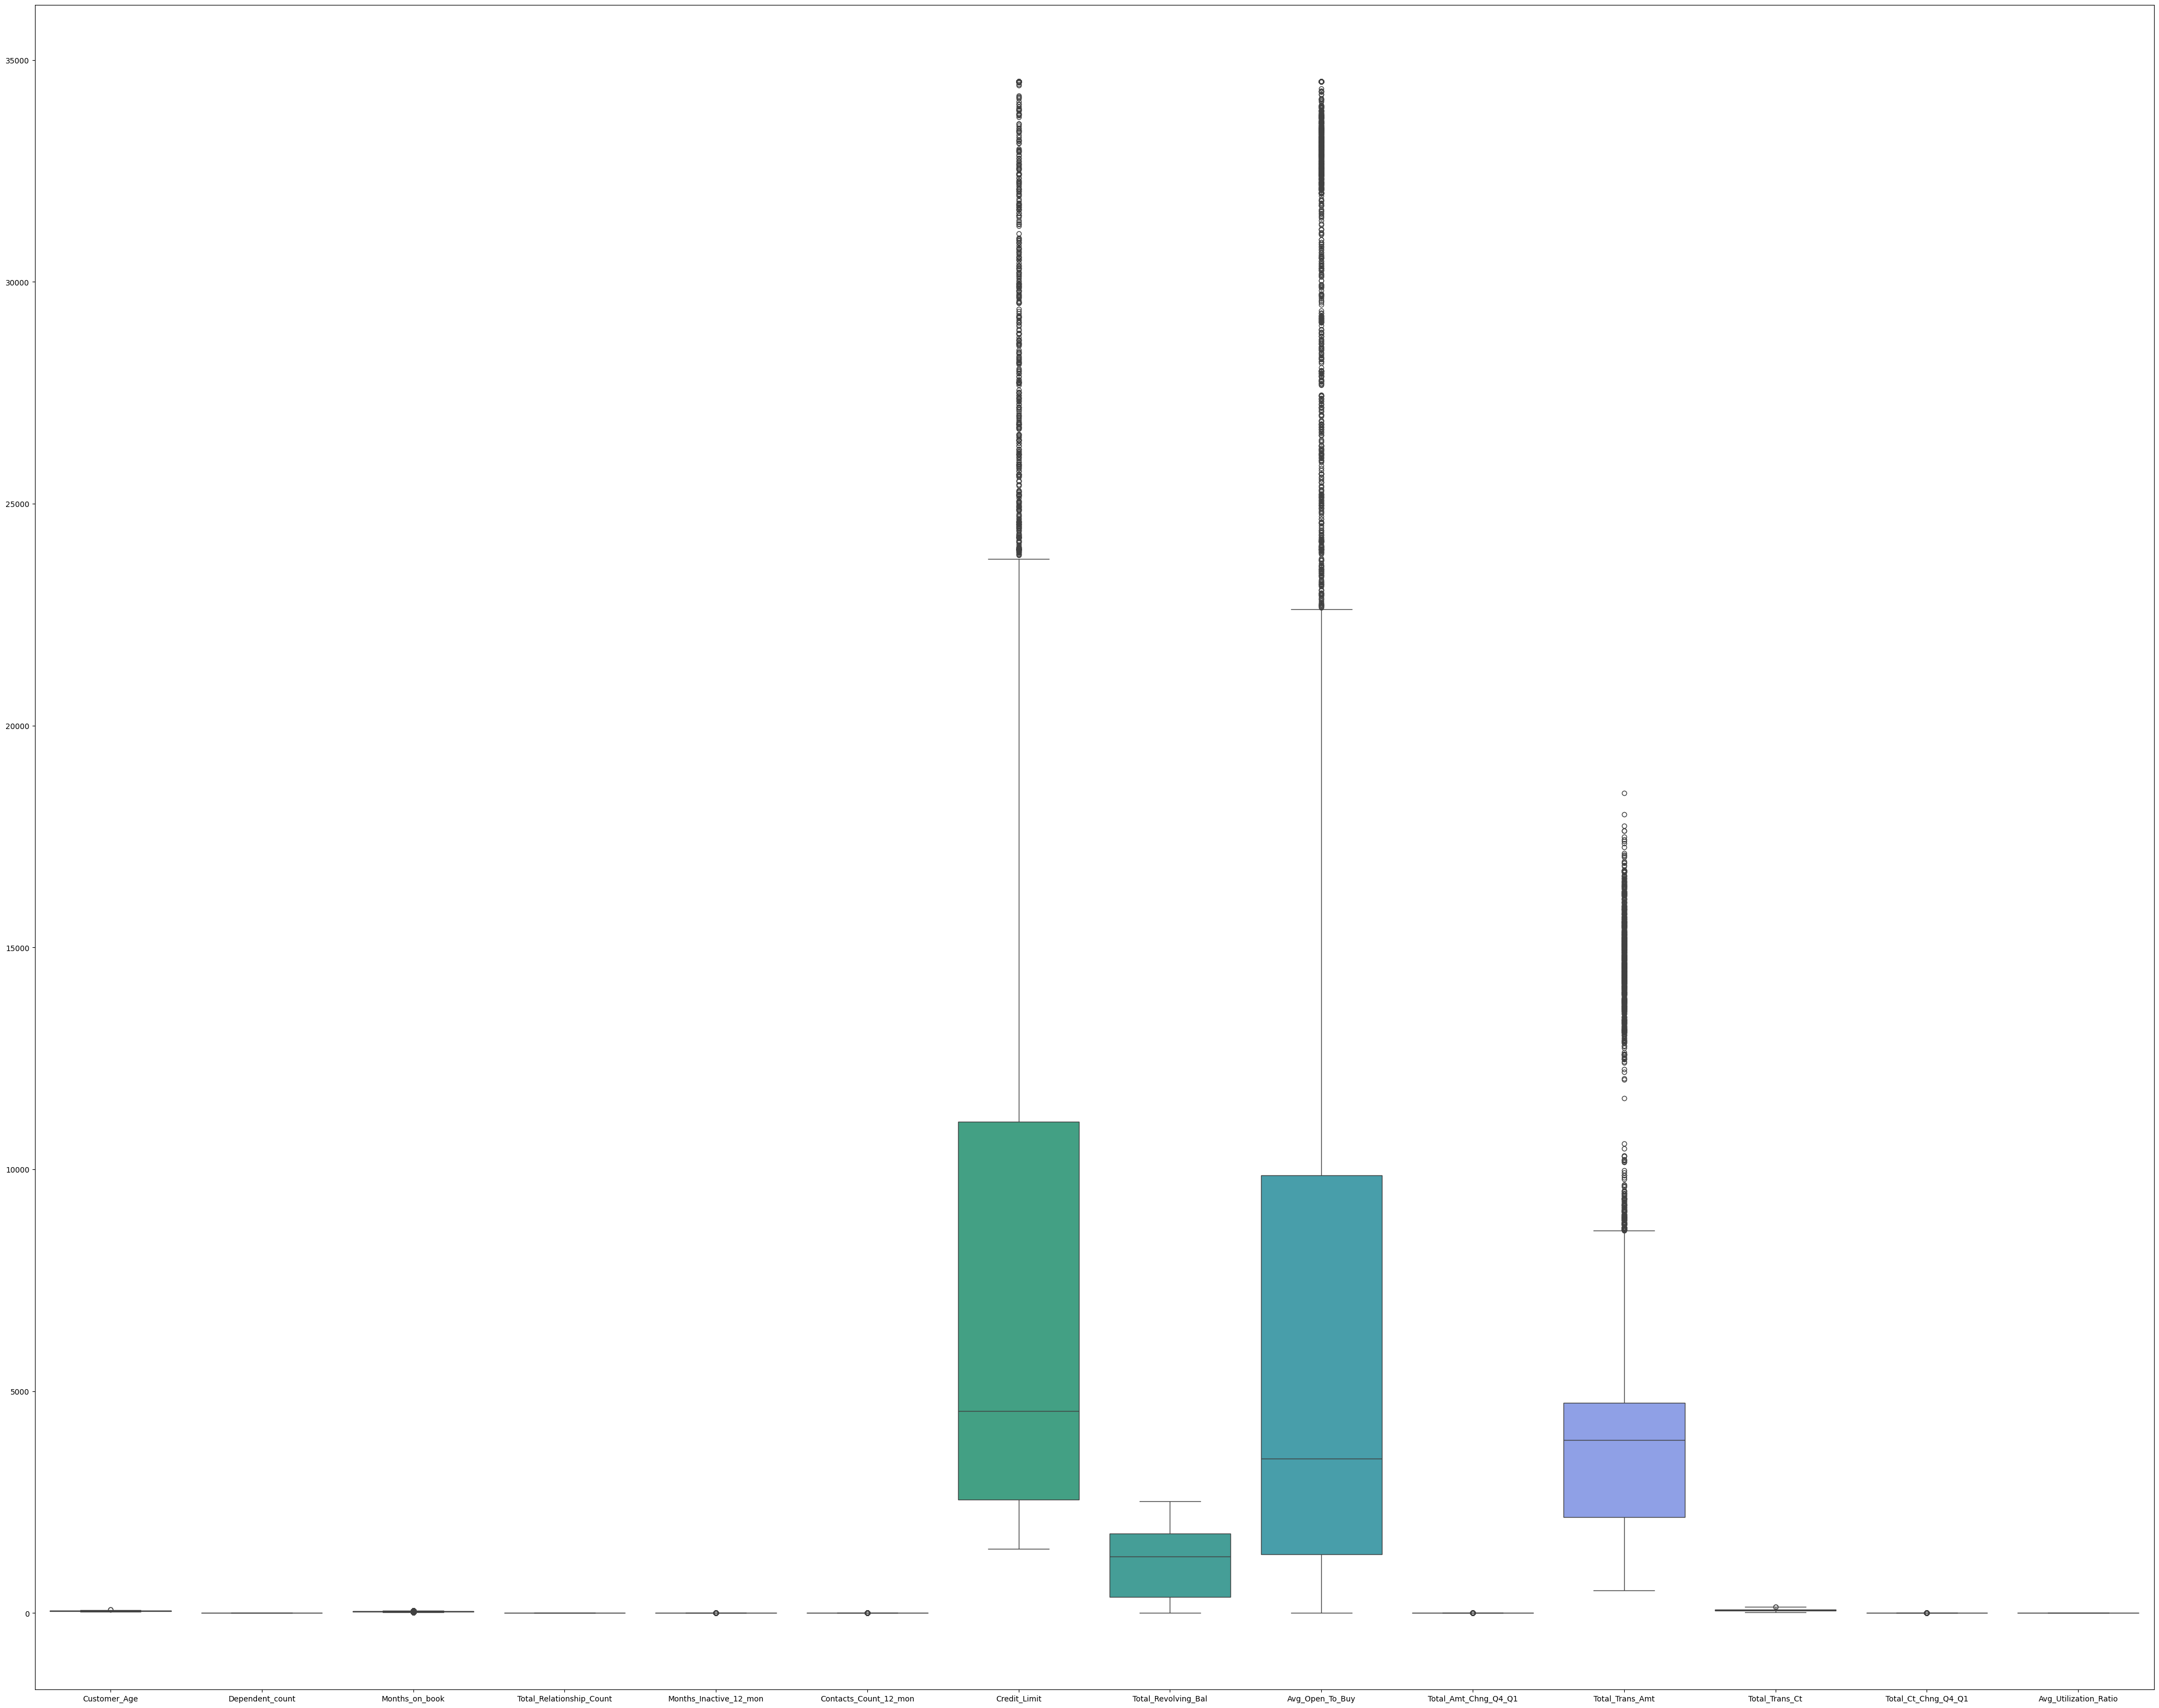

In [265]:
plt.figure(figsize=(50,40))
sns.boxplot(df)

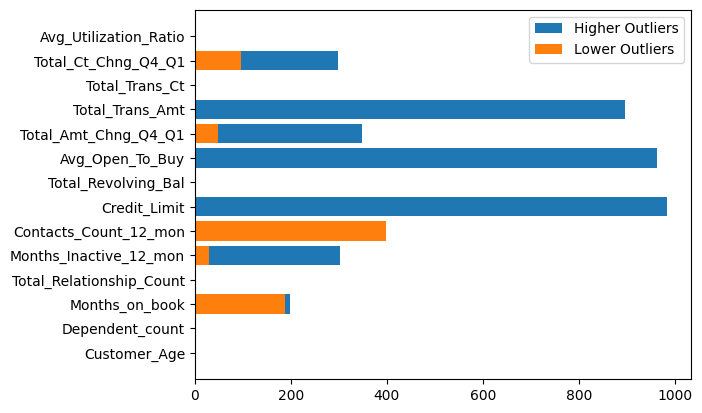

Customer_Age: 2, Customer_Age: 0, Total: 2
________________

Months_on_book: 198, Months_on_book: 188, Total: 386
________________

Months_Inactive_12_mon: 302, Months_Inactive_12_mon: 29, Total: 331
________________

Contacts_Count_12_mon: 230, Contacts_Count_12_mon: 399, Total: 629
________________

Credit_Limit: 984, Credit_Limit: 0, Total: 984
________________

Avg_Open_To_Buy: 963, Avg_Open_To_Buy: 0, Total: 963
________________

Total_Amt_Chng_Q4_Q1: 348, Total_Amt_Chng_Q4_Q1: 48, Total: 396
________________

Total_Trans_Amt: 896, Total_Trans_Amt: 0, Total: 896
________________

Total_Trans_Ct: 2, Total_Trans_Ct: 0, Total: 2
________________

Total_Ct_Chng_Q4_Q1: 298, Total_Ct_Chng_Q4_Q1: 96, Total: 394
________________



In [266]:
outlier_handler = OutlierHandling()

outlier_handler.plot(df)
outlier_handler.count_outliers_df(df)
# outlier_handler.display_outliers_df(df)


### outliers are too many, hence that we shouldn't just remove because its normal for banking to have high paying customers
##### we should go with log transformation for highly skewed (most outliers) features instead

In [267]:
cols = df.skew(numeric_only=True).index.tolist()
values = df.skew(numeric_only=True).values.tolist()

skew_result_df = pd.DataFrame([cols, values], index=['columns', 'values']).T 

skew_result_df.head()

,columns,values
0,Customer_Age,-0.033605
1,Dependent_count,-0.020826
2,Months_on_book,-0.106565
3,Total_Relationship_Count,-0.162452
4,Months_Inactive_12_mon,0.633061


<BarContainer object of 14 artists>

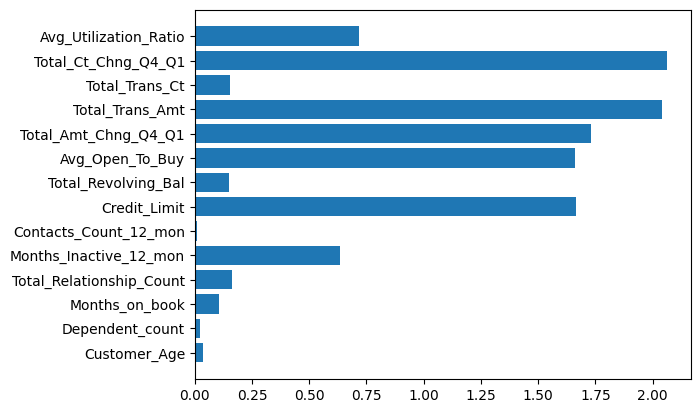

In [268]:
plt.barh(skew_result_df['columns'], skew_result_df['values'].abs())

In [269]:
highly_skewed_cols = skew_result_df[skew_result_df['values'].abs()>1]['columns'].tolist()
df_cleaned = df.copy()
df_cleaned[highly_skewed_cols] = np.log1p(df[highly_skewed_cols])


In [270]:
df_cleaned.skew(numeric_only=True)

Customer_Age               -0.033605
Dependent_count            -0.020826
Months_on_book             -0.106565
Total_Relationship_Count   -0.162452
Months_Inactive_12_mon      0.633061
Contacts_Count_12_mon       0.011006
Credit_Limit                0.457303
Total_Revolving_Bal        -0.148837
Avg_Open_To_Buy            -0.095298
Total_Amt_Chng_Q4_Q1        0.648440
Total_Trans_Amt             0.262780
Total_Trans_Ct              0.153673
Total_Ct_Chng_Q4_Q1         0.510172
Avg_Utilization_Ratio       0.718008
dtype: float64

<BarContainer object of 14 artists>

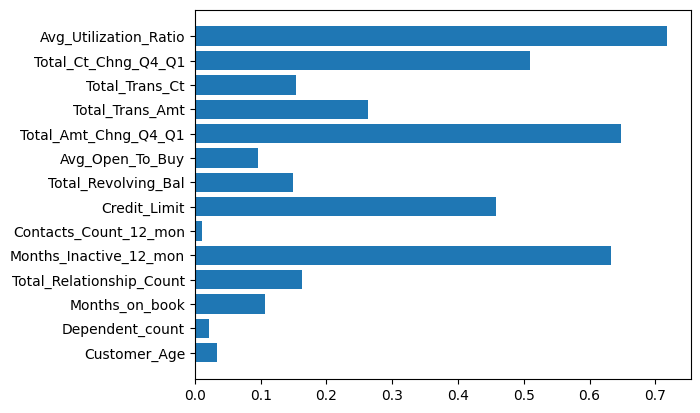

In [271]:
temp = df_cleaned.skew(numeric_only=True).abs()

plt.barh(temp.index, temp.values)

# Exploring Univariation demographics

In [272]:
df['Attrition_Flag'].unique()

array(['existing customer', 'attrited customer'], dtype=object)

In [273]:
df['churn'] = df['Attrition_Flag'].map({'Existing Customer':0, 'Attrited Customer':1})

count_existing: 8500
count_attrited: 1627
83.93%


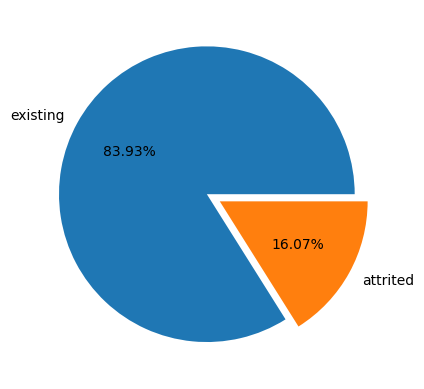

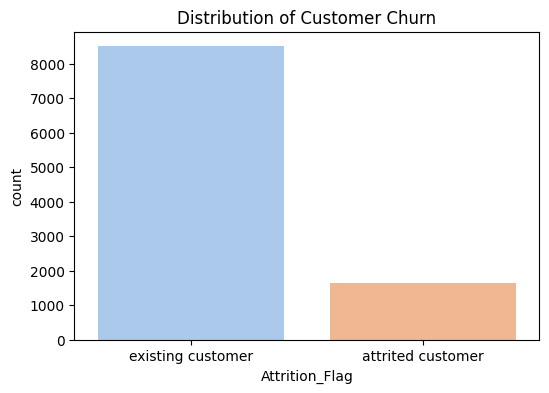

In [279]:
count_existing = 0
for i in df['Attrition_Flag']:
    if(i == 'existing customer'):
        count_existing+=1
count_attrited = df['Attrition_Flag'].count() - count_existing
count_total = df['Attrition_Flag'].count()
print(f'count_existing: {count_existing}')
print(f'count_attrited: {count_attrited}')

print(f'{round((count_existing/count_total)*100, 2)}%')

plt.pie([count_existing,count_attrited], labels=['existing', 'attrited'], autopct='%0.2f%%', explode=(0, .1))

plt.figure(figsize=(6,4))
sns.countplot(x='Attrition_Flag', data=df, hue='Attrition_Flag', palette='pastel')
plt.title('Distribution of Customer Churn')

plt.show()

(array([4769.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        5358.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

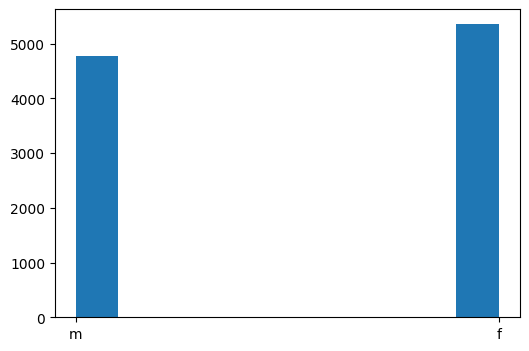

In [275]:
# demographic spreads
plt.figure(figsize=(6,4))
plt.hist(df_cleaned['Gender'])

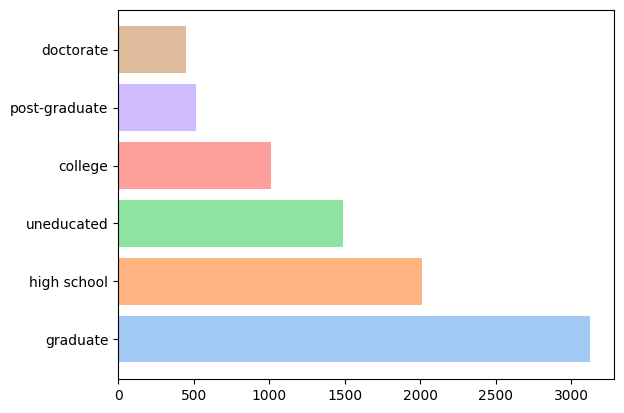

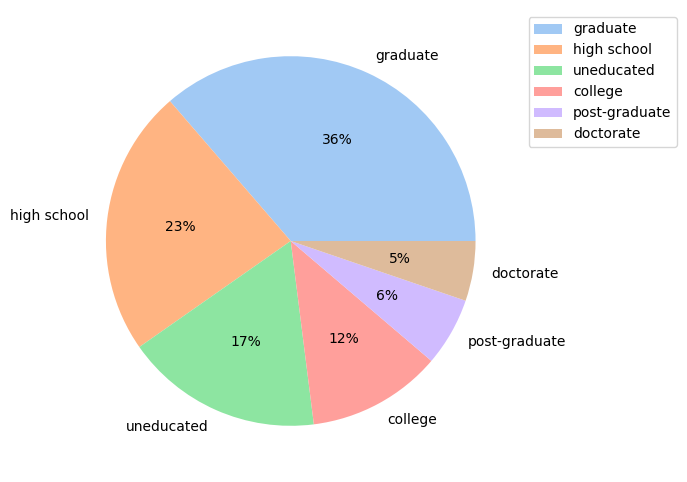

In [276]:
# plt.pie(df['Education_Level'].count())
temp_df1 = df.copy()


temp_df1['Education_Level'] = temp_df1['Education_Level'].str.strip()

temp_df1 = temp_df1[temp_df1['Education_Level'].str.lower() != 'unknown']

# edu_lvls = temp_df1['Education_Level'].unique().tolist()


edu_lvls = temp_df1['Education_Level'].value_counts().index.tolist()
edu_lvls_values = temp_df1['Education_Level'].value_counts().values.tolist()


plt.barh(edu_lvls, edu_lvls_values, color = sns.color_palette('pastel', len(edu_lvls)))
plt.show()
plt.figure(figsize=(10,6))
plt.pie(edu_lvls_values, labels=edu_lvls, autopct='%.0f%%', colors=sns.color_palette('pastel', len(edu_lvls)))
plt.legend(edu_lvls, bbox_to_anchor = (1,1))
plt.show()



In [277]:
# lets do the income category
df_cleaned['Income_Category'].unique()

array(['$60k - $80k', 'less than $40k', '$80k - $120k', '$40k - $60k',
       '$120k +', 'unknown'], dtype=object)

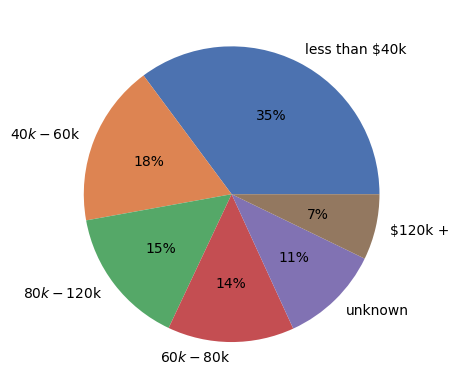

In [299]:
temp_df1 = df_cleaned.copy()
# df_cleaned['Income_Category'].value_counts().to_dict
income_class = df_cleaned['Income_Category'].value_counts().index
income_counts = df_cleaned['Income_Category'].value_counts().values

# we use the names as a labels in the pie chart 
# we use the values as the data in the pie chart
plt.pie(income_counts, labels=income_class, autopct="%.f%%", colors=sns.color_palette('deep', len(income_class)))
plt.show()